# Biblioteka Seaborn - Część 2 (Finał)

## Wykresy kategoryczne, Heatmapy i stylowanie

## Setup - Import i dane

In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

%matplotlib inline
sns.set_theme()

# Wczytaj dane
df_prac = pd.read_csv('../data/pracownicy.csv')
df_pogoda = pd.read_csv('../data/pogoda.csv')
df_sprzedaz = pd.read_csv('../data/sprzedaz.csv')
df_sprzedaz['data'] = pd.to_datetime(df_sprzedaz['data'])
df_sprzedaz['wartosc_sprzedazy'] = df_sprzedaz['kwota'] * df_sprzedaz['ilosc']

print("Dane wczytane!")

Dane wczytane!


## 1. Wykresy kategoryczne

Wykresy kategoryczne pokazują zależności między zmiennymi kategorycznymi a liczbowymi.

### 1.1 Bar plot (`barplot`)

**Uwaga:** `barplot` w Seaborn to NIE to samo co `bar` w Matplotlib!

Seaborn `barplot` automatycznie:
- Oblicza średnią dla każdej kategorii
- Dodaje przedziały ufności (error bars)

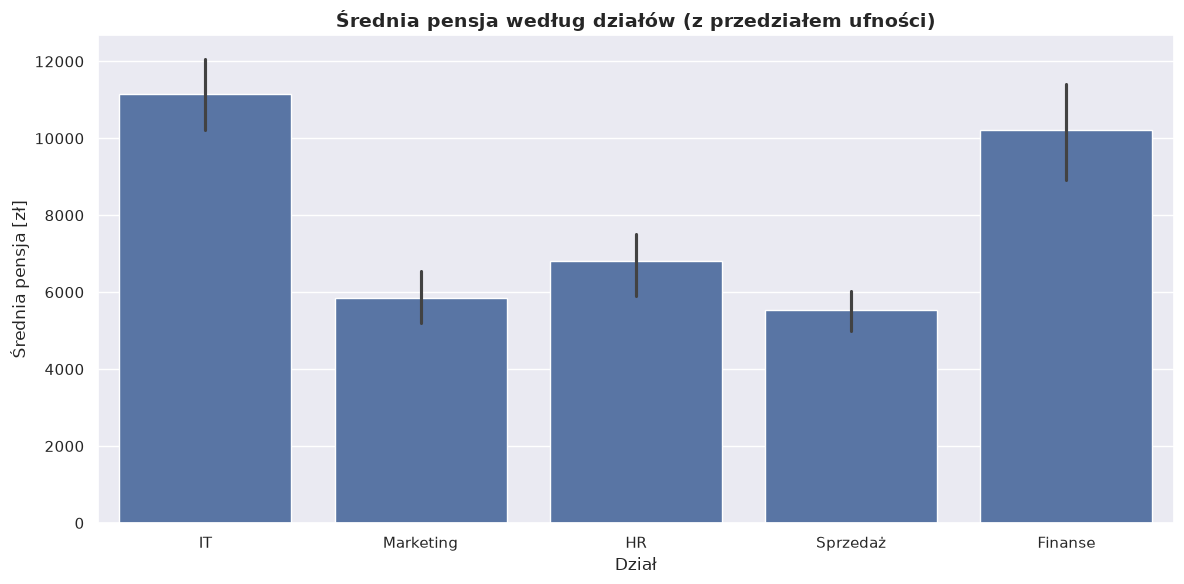

Czarne linie to przedziały ufności (95% domyślnie)
Pokazują niepewność oszacowania średniej


In [3]:
# Bar plot - średnia pensja według działu
plt.figure(figsize=(12, 6))

sns.barplot(data=df_prac, x='dzial', y='pensja')

plt.title('Średnia pensja według działów (z przedziałem ufności)', 
          fontsize=14, fontweight='bold')
plt.xlabel('Dział')
plt.ylabel('Średnia pensja [zł]')
plt.tight_layout()
plt.show()

print("Czarne linie to przedziały ufności (95% domyślnie)")
print("Pokazują niepewność oszacowania średniej")

**⚠️ WAŻNE - Error bary w Seaborn vs Matplotlib:**

**Seaborn `barplot()`:**
- Error bary = **95% przedział ufności (CI)** dla średniej (domyślnie)
- Mówi: "Prawdziwa średnia populacji jest **prawdopodobnie** w tym przedziale"
- To przedział **niepewności oszacowania**, nie rozkład danych!

**Matplotlib `bar()` + `yerr`:**
- Zwykle pokazuje **kwartyle** (Q1, Q3) lub **odchylenie standardowe**
- Mówi: "Tak dane są **rozrzucone**"
- To informacja o **zmienności danych**, nie o średniej!

**Różnica:**
```python
# MATPLOTLIB - kwartyle lub std
q1 = df.groupby('dzial')['pensja'].quantile(0.25)
q3 = df.groupby('dzial')['pensja'].quantile(0.75)
plt.bar(..., yerr=[q1, q3])  # Pokazuje rozrzut danych

# SEABORN - przedział ufności
sns.barplot(...)  # Pokazuje niepewność oszacowania średniej (95% CI)
```

**Jak zmienić w Seaborn:**
```python
sns.barplot(..., errorbar='sd')    # Odchylenie standardowe (jak często w matplotlib)
sns.barplot(..., errorbar='se')    # Błąd standardowy
sns.barplot(..., errorbar=('ci', 99))  # 99% przedział ufności
sns.barplot(..., errorbar=None)    # Bez error barów
```

### Bar plot z grupowaniem (`hue`)

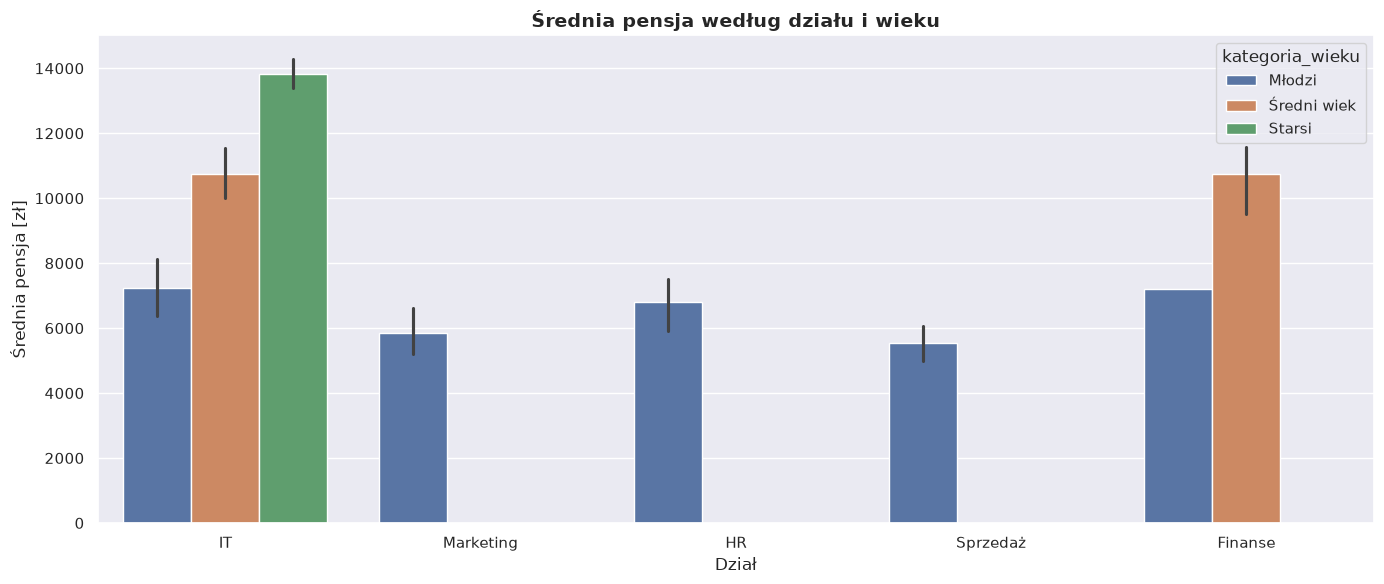

In [5]:
# Dodajmy kolumnę z kategorią wieku
df_prac['kategoria_wieku'] = pd.cut(df_prac['wiek'], 
                                     bins=[0, 35, 50, 100], 
                                     labels=['Młodzi', 'Średni wiek', 'Starsi'])

plt.figure(figsize=(14, 6))

sns.barplot(data=df_prac, 
            x='dzial', 
            y='pensja',
            hue='kategoria_wieku')  # Grupuj według wieku

plt.title('Średnia pensja według działu i wieku', fontsize=14, fontweight='bold')
plt.xlabel('Dział')
plt.ylabel('Średnia pensja [zł]')
plt.tight_layout()
plt.show()

### 1.2 Count plot (`countplot`)

Count plot to bar plot, który liczy ile jest obserwacji w każdej kategorii.

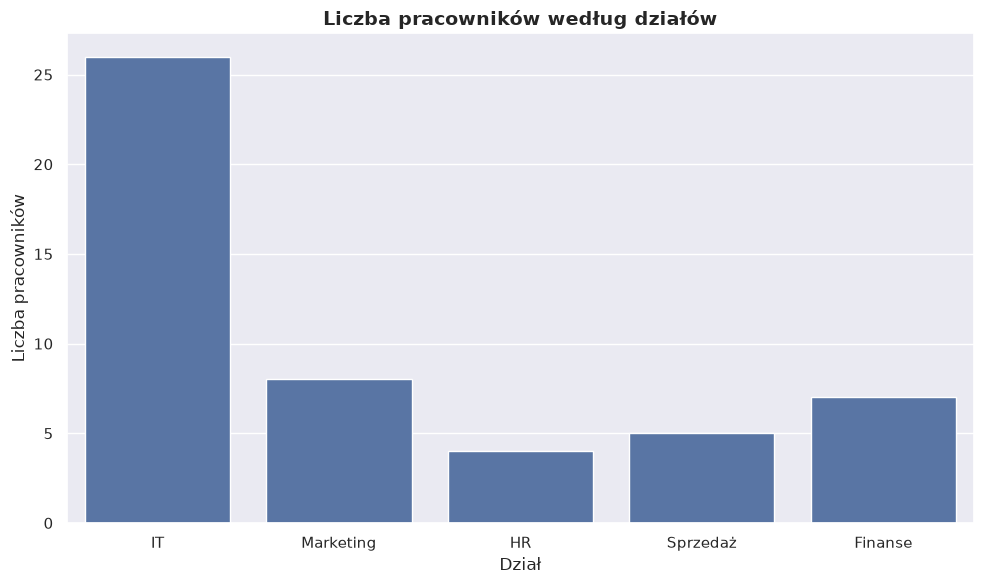

In [6]:
# Count plot - ile pracowników w każdym dziale
plt.figure(figsize=(10, 6))

sns.countplot(data=df_prac, x='dzial')

plt.title('Liczba pracowników według działów', fontsize=14, fontweight='bold')
plt.xlabel('Dział')
plt.ylabel('Liczba pracowników')
plt.tight_layout()
plt.show()

### Count plot z grupowaniem

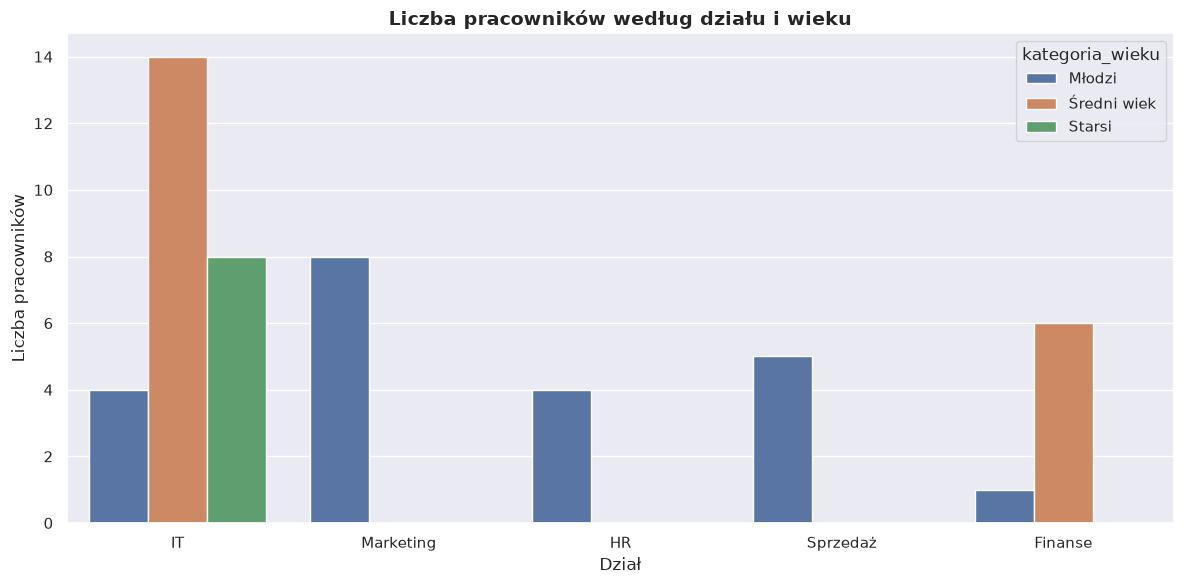

In [7]:
# Count plot z hue
plt.figure(figsize=(12, 6))

sns.countplot(data=df_prac, x='dzial', hue='kategoria_wieku')

plt.title('Liczba pracowników według działu i wieku', fontsize=14, fontweight='bold')
plt.xlabel('Dział')
plt.ylabel('Liczba pracowników')
plt.tight_layout()
plt.show()

### 1.3 Cat plot - uniwersalna funkcja kategoryczna

`catplot` to uniwersalna funkcja, która może tworzyć różne typy wykresów + faceting!

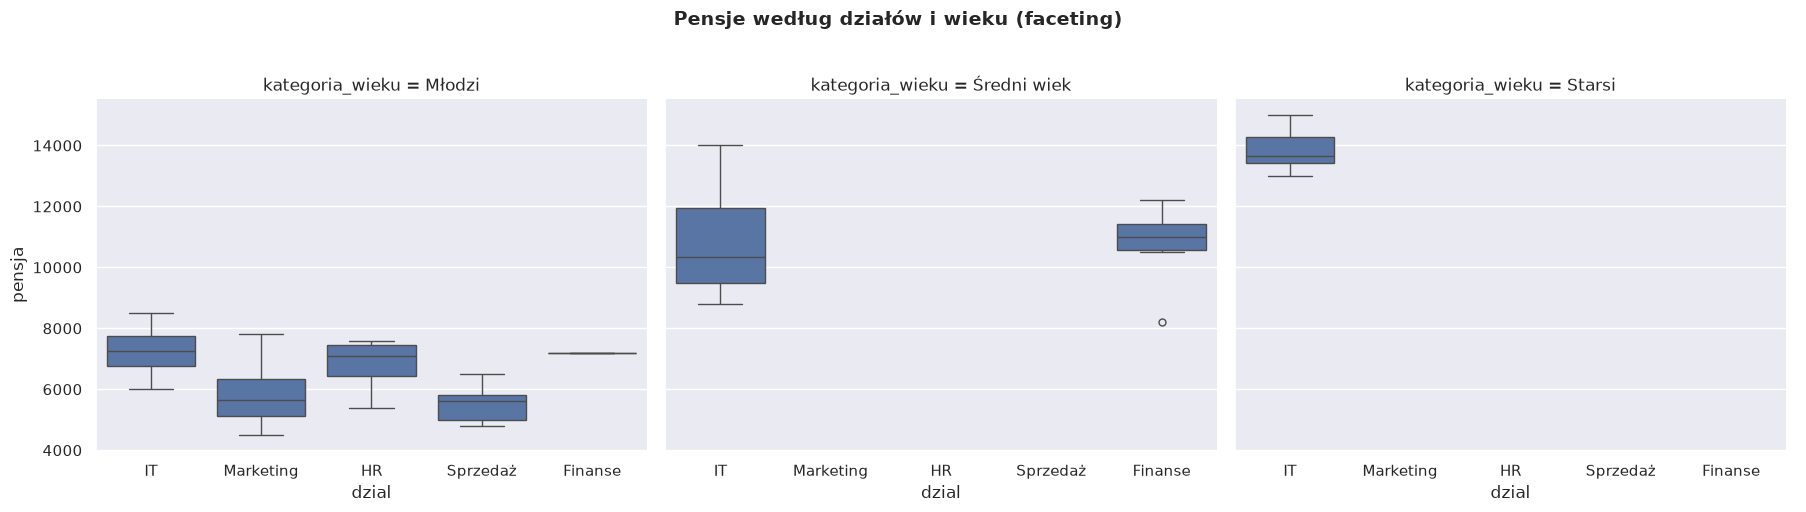

In [6]:
# Catplot z facetami
g = sns.catplot(data=df_prac,
                x='dzial',
                y='pensja',
                col='kategoria_wieku',   # Osobny panel dla każdej kategorii
                kind='box',              # Typ: 'box', 'violin', 'bar', 'count', 'strip', 'swarm'
                height=5,
                aspect=1.2)

g.fig.suptitle('Pensje według działów i wieku (faceting)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 1.4 Strip plot i Swarm plot

Pokazują wszystkie punkty danych.

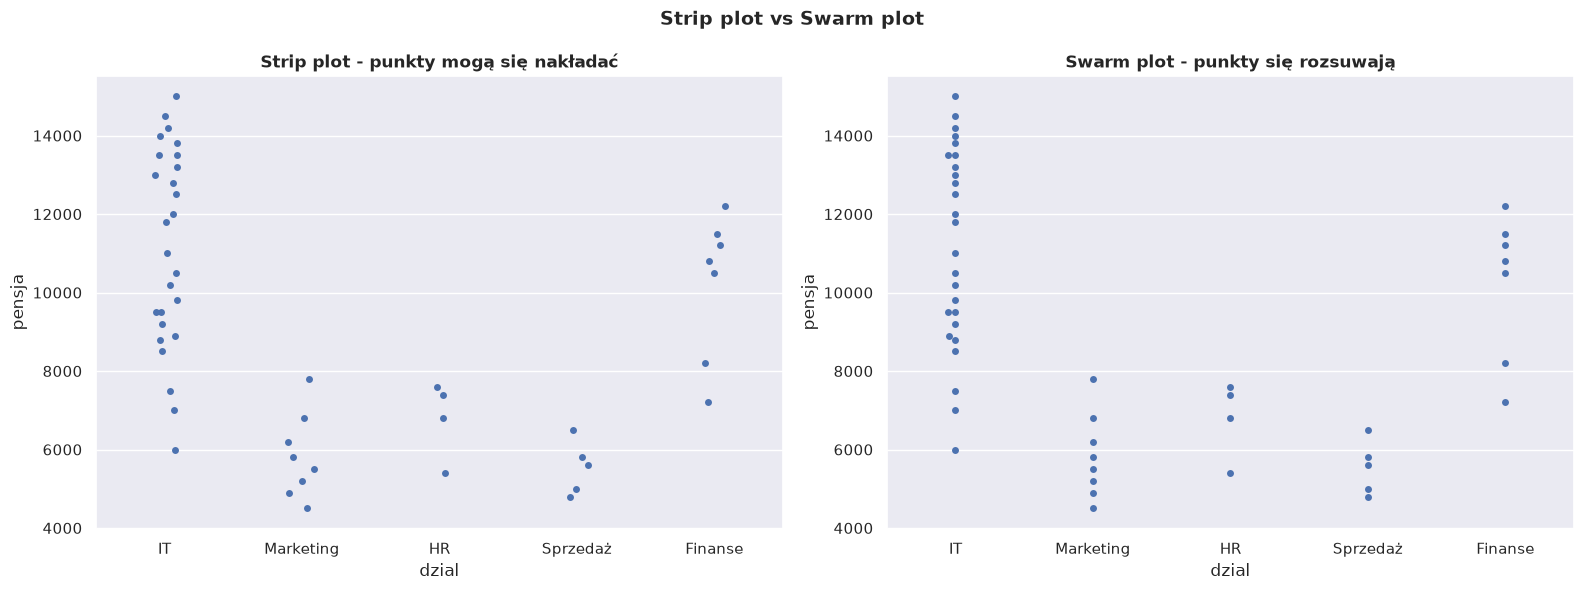

Strip plot: szybszy, ale punkty mogą się nakładać
Swarm plot: ładniejszy, każdy punkt widoczny (lepszy dla małych zbiorów)


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Strip plot - punkty się nakładają
sns.stripplot(data=df_prac, x='dzial', y='pensja', ax=axes[0])
axes[0].set_title('Strip plot - punkty mogą się nakładać', fontsize=12, fontweight='bold')

# Swarm plot - punkty się NIE nakładają
sns.swarmplot(data=df_prac, x='dzial', y='pensja', ax=axes[1])
axes[1].set_title('Swarm plot - punkty się rozsuwają', fontsize=12, fontweight='bold')

plt.suptitle('Strip plot vs Swarm plot', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("Strip plot: szybszy, ale punkty mogą się nakładać")
print("Swarm plot: ładniejszy, każdy punkt widoczny (lepszy dla małych zbiorów)")

### Łączenie wykresów - Box + Swarm

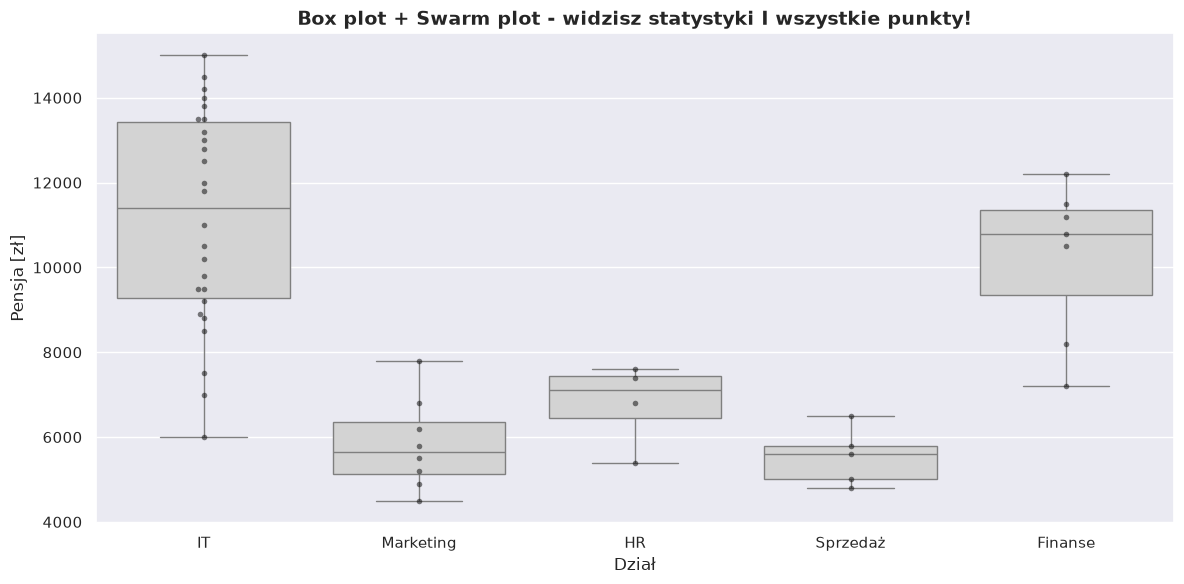

In [9]:
# Box plot + swarm plot = super wizualizacja!
plt.figure(figsize=(12, 6))

# Najpierw box plot
sns.boxplot(data=df_prac, x='dzial', y='pensja', color='lightgray')

# Potem swarm plot na wierzchu
sns.swarmplot(data=df_prac, x='dzial', y='pensja', color='black', alpha=0.5, size=4)

plt.title('Box plot + Swarm plot - widzisz statystyki I wszystkie punkty!', 
          fontsize=14, fontweight='bold')
plt.xlabel('Dział')
plt.ylabel('Pensja [zł]')
plt.tight_layout()
plt.show()

---
## Ćwiczenie 3.5 (w trakcie) - Count plot

**Cel:** Stworzyć count plot sprzedaży.

**Zadanie:**
1. Użyj danych sprzedażowych
2. Utwórz count plot pokazujący liczbę transakcji według produktu
3. Posortuj produkty od najmniejszej do największej liczby transakcji
4. Użyj wykresu poziomego (zamień x i y)
5. Dodaj tytuł

**Wskazówka:** Użyj parametru `order` z posortowaną listą produktów

**Czas:** 10 minut

In [10]:
# TWÓJ KOD TUTAJ



<details>
<summary><b>🔍 Kliknij, aby zobaczyć rozwiązanie</b></summary>

```python
# Posortuj produkty według liczby transakcji
order = df_sprzedaz['produkt'].value_counts().index

plt.figure(figsize=(10, 8))

sns.countplot(data=df_sprzedaz, y='produkt', order=order)

plt.title('Liczba transakcji według produktu', fontsize=14, fontweight='bold')
plt.xlabel('Liczba transakcji')
plt.ylabel('Produkt')
plt.tight_layout()
plt.show()

# Statystyki
print("Top 3 produkty według liczby transakcji:")
print(df_sprzedaz['produkt'].value_counts().head(3))
```

</details>

---
## 2. Heatmap i macierz korelacji

Heatmapa to wykres pokazujący wartości jako kolory. Idealna do macierzy korelacji!

### 2.1 Podstawowa heatmapa

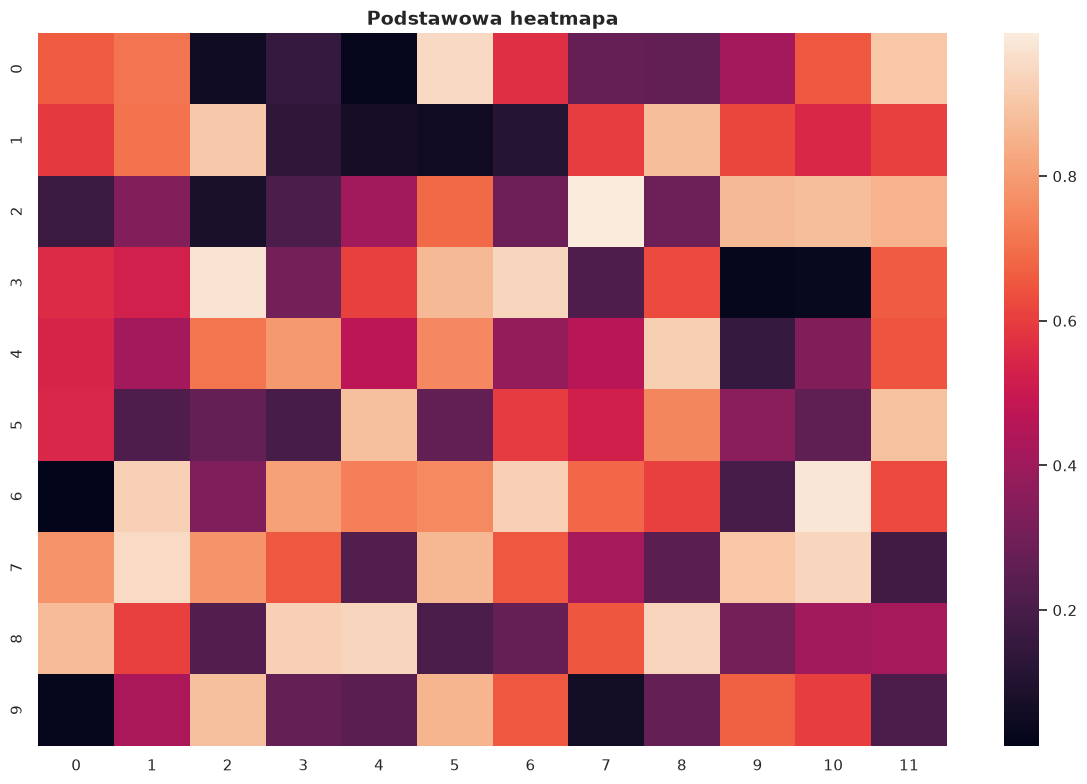

In [10]:
# Prosty przykład - losowa macierz
data = np.random.rand(10, 12)

plt.figure(figsize=(12, 8))

sns.heatmap(data)

plt.title('Podstawowa heatmapa', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 2.2 Macierz korelacji

Najczęstsze zastosowanie heatmapy - wizualizacja korelacji między zmiennymi!

In [12]:
# Macierz korelacji dla danych pracowników
# Wybierz tylko kolumny numeryczne
numeric_cols = ['wiek', 'pensja', 'staz']
corr_matrix = df_prac[numeric_cols].corr()

print("Macierz korelacji:")
print(corr_matrix)

Macierz korelacji:
            wiek    pensja      staz
wiek    1.000000  0.986945  0.995489
pensja  0.986945  1.000000  0.975980
staz    0.995489  0.975980  1.000000


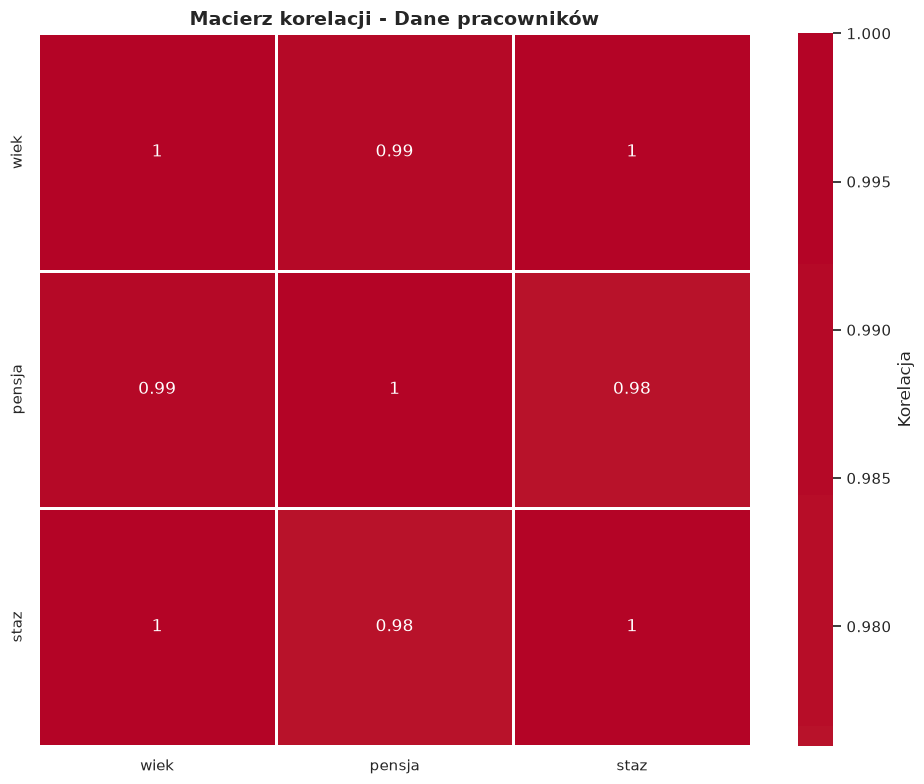

Interpretacja:
- Czerwony = korelacja dodatnia (rosną razem)
- Niebieski = korelacja ujemna (jeden rośnie, drugi maleje)
- Biały = brak korelacji
- Wartości od -1 do 1


In [13]:
# Heatmapa korelacji
plt.figure(figsize=(10, 8))

sns.heatmap(corr_matrix,
            annot=True,           # Pokaż wartości
            cmap='coolwarm',      # Paleta: niebiesko-czerwona
            center=0,             # Wyśrodkuj na 0
            square=True,          # Kwadraty
            linewidths=1,         # Linie między komórkami
            cbar_kws={'label': 'Korelacja'})

plt.title('Macierz korelacji - Dane pracowników', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("Interpretacja:")
print("- Czerwony = korelacja dodatnia (rosną razem)")
print("- Niebieski = korelacja ujemna (jeden rośnie, drugi maleje)")
print("- Biały = brak korelacji")
print("- Wartości od -1 do 1")

### Heatmapa z maską (ukryj górny trójkąt)

**Dlaczego ukrywamy górny trójkąt?**

Macierz korelacji jest **symetryczna** - wartość w [i, j] = wartość w [j, i]:
```
         wiek  pensja  staz
wiek     1.00   0.99   0.99
pensja   0.99   1.00   0.98  ← Te same wartości
staz     0.99   0.98   1.00     po obu stronach przekątnej
```

Pokazywanie obu połówek to **duplikacja** - wystarczy jedna!

In [ ]:
# Macierz jest symetryczna - wystarczy połowa
plt.figure(figsize=(10, 8))

# Utwórz maskę dla górnego trójkąta
# np.triu = numpy triangle upper - zwraca górny trójkąt macierzy (powyżej przekątnej)
# np.ones_like(corr_matrix) tworzy macierz jedynek o tym samym kształcie
# dtype=bool konwertuje na True/False
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# Przykład jak działa maska (dla macierzy 3×3):
# mask = [[True,  True,  True],     ← Górny trójkąt (ukryty)
#         [False, True,  True],     ← Przekątna + górny trójkąt
#         [False, False, True]]     ← Tylko przekątna

sns.heatmap(corr_matrix,
            mask=mask,            # Ukryj górny trójkąt
            annot=True,
            cmap='coolwarm',
            center=0,
            square=True,
            linewidths=1,
            fmt='.2f',            # Format liczb
            cbar_kws={'label': 'Korelacja'})

plt.title('Macierz korelacji (bez duplikacji)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("💡 np.triu (triangle upper) = górny trójkąt")
print("   Ukrywamy go, bo macierz jest symetryczna - te same wartości po obu stronach")

### Heatmapa danych pogodowych

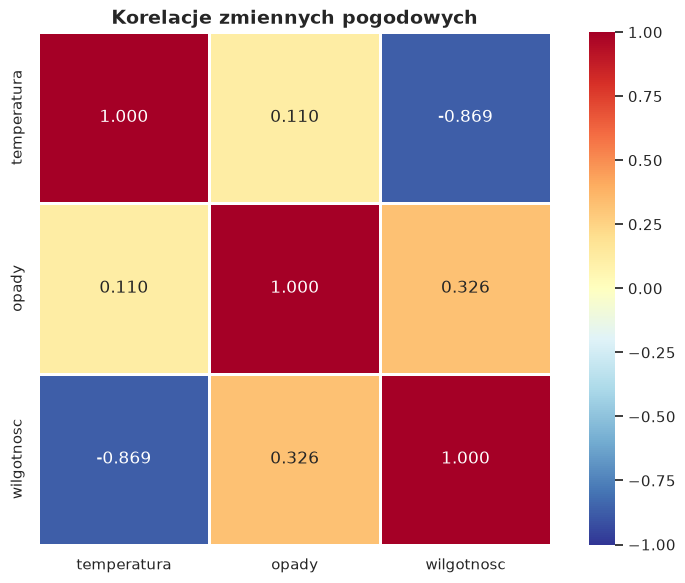


Wnioski:
Temperatura vs Wilgotność: -0.869
Temperatura vs Opady: 0.110


In [16]:
# Korelacje dla danych pogodowych
corr_pogoda = df_pogoda[['temperatura', 'opady', 'wilgotnosc']].corr()

plt.figure(figsize=(8, 6))

sns.heatmap(corr_pogoda,
            annot=True,
            cmap='RdYlBu_r',       # Inna paleta
            center=0,
            square=True,
            linewidths=2,
            linecolor='white',
            fmt='.3f',
            vmin=-1, vmax=1)      # Zakres od -1 do 1

plt.title('Korelacje zmiennych pogodowych', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nWnioski:")
print(f"Temperatura vs Wilgotność: {corr_pogoda.loc['temperatura', 'wilgotnosc']:.3f}")
print(f"Temperatura vs Opady: {corr_pogoda.loc['temperatura', 'opady']:.3f}")

---
## Ćwiczenie 3.7 (w trakcie) - Heatmap korelacji

**Cel:** Stworzyć heatmapę korelacji dla danych sprzedażowych.

**Zadanie:**
1. Z danych sprzedażowych wybierz kolumny numeryczne: kwota, ilosc, wartosc_sprzedazy
2. Oblicz macierz korelacji
3. Utwórz heatmapę z:
   - Adnotacjami (annot=True)
   - Paletą 'coolwarm'
   - Kwadratowymi komórkami
4. Dodaj tytuł
5. Zinterpretuj wyniki - które zmienne są najsilniej skorelowane?

**Czas:** 10 minut

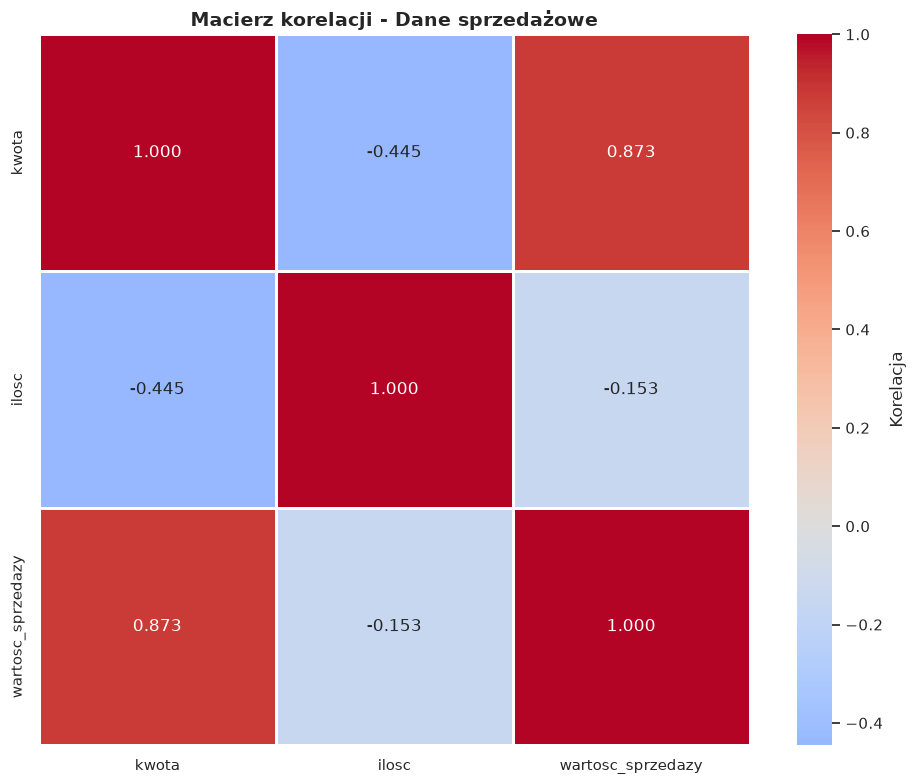

INTERPRETACJA

1. Kwota vs Wartość sprzedaży: 0.873
   -> Bardzo silna korelacja - logiczne, bo wartość = kwota × ilość

2. Ilość vs Wartość sprzedaży: -0.153
   -> Silna korelacja - też logiczne

3. Kwota vs Ilość: -0.445
   -> Umiarkowana korelacja


In [17]:
# TWÓJ KOD TUTAJ



<details>
<summary><b>🔍 Kliknij, aby zobaczyć rozwiązanie</b></summary>

```python
# Wybierz kolumny numeryczne
cols = ['kwota', 'ilosc', 'wartosc_sprzedazy']
corr_sprzedaz = df_sprzedaz[cols].corr()

plt.figure(figsize=(10, 8))

sns.heatmap(corr_sprzedaz,
            annot=True,
            cmap='coolwarm',
            center=0,
            square=True,
            linewidths=2,
            fmt='.3f',
            cbar_kws={'label': 'Korelacja'})

plt.title('Macierz korelacji - Dane sprzedażowe', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Interpretacja
print("="*60)
print("INTERPRETACJA")
print("="*60)
print(f"\n1. Kwota vs Wartość sprzedaży: {corr_sprzedaz.loc['kwota', 'wartosc_sprzedazy']:.3f}")
print("   -> Bardzo silna korelacja - logiczne, bo wartość = kwota × ilość")

print(f"\n2. Ilość vs Wartość sprzedaży: {corr_sprzedaz.loc['ilosc', 'wartosc_sprzedazy']:.3f}")
print("   -> Silna korelacja - też logiczne")

print(f"\n3. Kwota vs Ilość: {corr_sprzedaz.loc['kwota', 'ilosc']:.3f}")
if abs(corr_sprzedaz.loc['kwota', 'ilosc']) < 0.3:
    print("   -> Słaba korelacja - drogie produkty nie są kupowane częściej!")
else:
    print("   -> Umiarkowana korelacja")
```

</details>

---
## 3. Pairplot - wszystkie zmienne naraz!

**Pairplot** to narzędzie do szybkiej analizy wielu zmiennych jednocześnie.

Tworzy siatkę wykresów:
- **Diagonala**: rozkład każdej zmiennej (histogram lub KDE)
- **Poza diagonalą**: scatter plots wszystkich par zmiennych

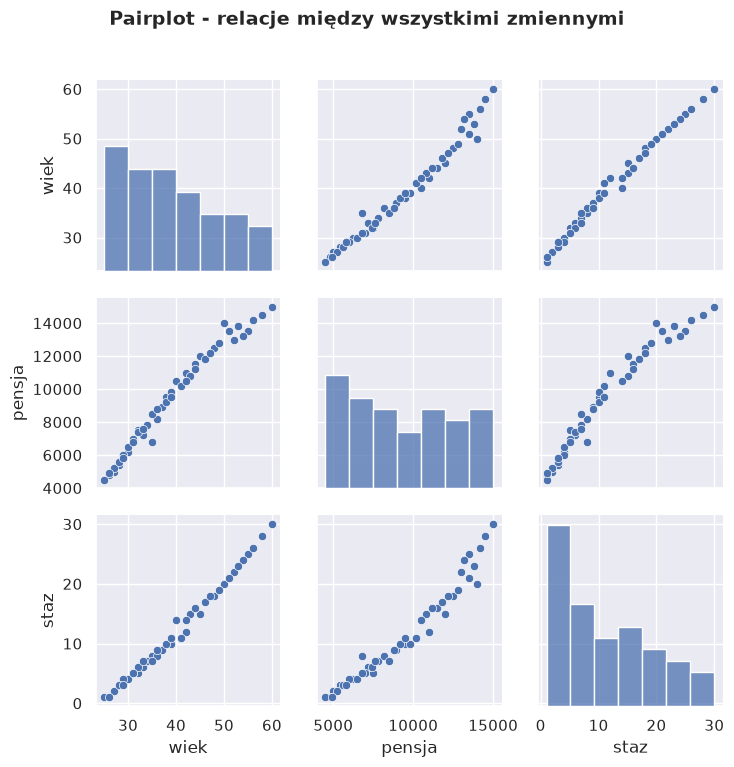

Pairplot w jednej linii kodu pokazuje:
- 3 histogramy (diagonala)
- 6 scatter plotów (wszystkie pary)

To byłoby ~50 linii kodu w Matplotlib!


In [18]:
# Pairplot dla danych pracowników
g = sns.pairplot(df_prac[['wiek', 'pensja', 'staz']])

g.fig.suptitle('Pairplot - relacje między wszystkimi zmiennymi', 
               fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("Pairplot w jednej linii kodu pokazuje:")
print("- 3 histogramy (diagonala)")
print("- 6 scatter plotów (wszystkie pary)")
print("\nTo byłoby ~50 linii kodu w Matplotlib!")

### Pairplot z kolorowaniem według kategorii

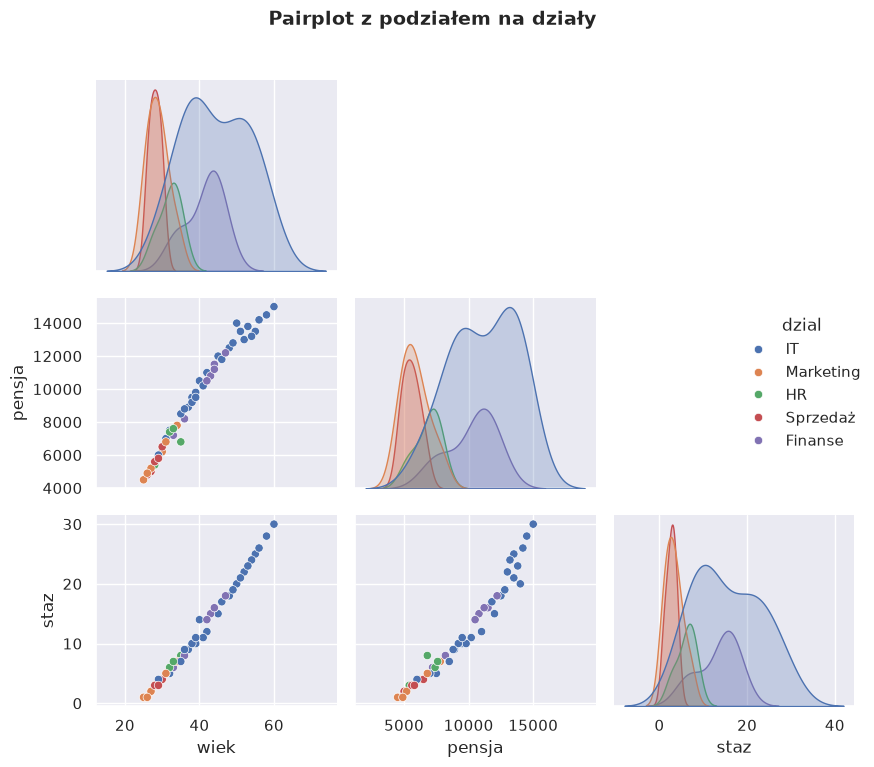

In [19]:
# Pairplot z hue
g = sns.pairplot(df_prac[['wiek', 'pensja', 'staz', 'dzial']],
                 hue='dzial',           # Koloruj według działu
                 diag_kind='kde',       # Na diagonali KDE zamiast histogramu
                 corner=True)           # Tylko dolny trójkąt (mniej duplikacji)

g.fig.suptitle('Pairplot z podziałem na działy', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### Pairplot z regresją

In [ ]:
# Pairplot z liniami regresji
g = sns.pairplot(df_prac[['wiek', 'pensja', 'staz']],
                 kind='reg',            # Dodaj linie regresji
                 diag_kind='kde',
                 plot_kws={'line_kws': {'color': 'red', 'linewidth': 2},    # Czerwona linia!
                           'scatter_kws': {'alpha': 0.5}})                   # Punkty półprzezroczyste

g.fig.suptitle('Pairplot z regresją liniową', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("💡 plot_kws={'line_kws': {'color': 'red'}} - zagnieżdżenie w plot_kws!")
print("   Teraz czerwona linia jest WIDOCZNA na tle niebieskich punktów!")

---
## Ćwiczenie 3.9 (w trakcie) - Pairplot danych

**Cel:** Stworzyć pairplot dla danych pogodowych.

**Zadanie:**
1. Użyj danych pogodowych (pierwsze 100 wierszy dla szybkości)
2. Wybierz kolumny: temperatura, opady, wilgotnosc
3. Utwórz pairplot
4. Użyj diag_kind='kde'
5. Dodaj tytuł do całej figury
6. Na podstawie pairplota odpowiedz:
   - Które zmienne są najbardziej skorelowane?
   - Czy widzisz jakieś nietypowe wzorce?

**Czas:** 10 minut

In [22]:
# TWÓJ KOD TUTAJ



<details>
<summary><b>🔍 Kliknij, aby zobaczyć rozwiązanie</b></summary>

```python
# Pairplot dla danych pogodowych
dane = df_pogoda[['temperatura', 'opady', 'wilgotnosc']].head(100)

g = sns.pairplot(dane, diag_kind='kde')

g.fig.suptitle('Pairplot - zmienne pogodowe', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Analiza
print("="*60)
print("ANALIZA PAIRPLOT")
print("="*60)

# Korelacje
corr = dane.corr()
print("\nKorelacje:")
print(corr)

print("\nWnioski:")
print("1. TEMPERATURA vs WILGOTNOŚĆ:")
if corr.loc['temperatura', 'wilgotnosc'] < -0.3:
    print("   -> Ujemna korelacja: ciepło = mniejsza wilgotność")
elif corr.loc['temperatura', 'wilgotnosc'] > 0.3:
    print("   -> Dodatnia korelacja: ciepło = większa wilgotność")
else:
    print("   -> Słaba korelacja")

print("\n2. ROZKŁADY (diagonala):")
print("   -> Sprawdź czy są symetryczne czy skośne")

print("\n3. WARTOŚCI ODSTAJĄCE:")
print("   -> Szukaj punktów daleko od 'chmury' punktów")
```

</details>

---
## 4. Stylowanie w Seaborn

Seaborn ma wbudowane style, które sprawiają, że wykresy wyglądają profesjonalnie.

### 4.1 Tematy (`set_theme`, `set_style`)

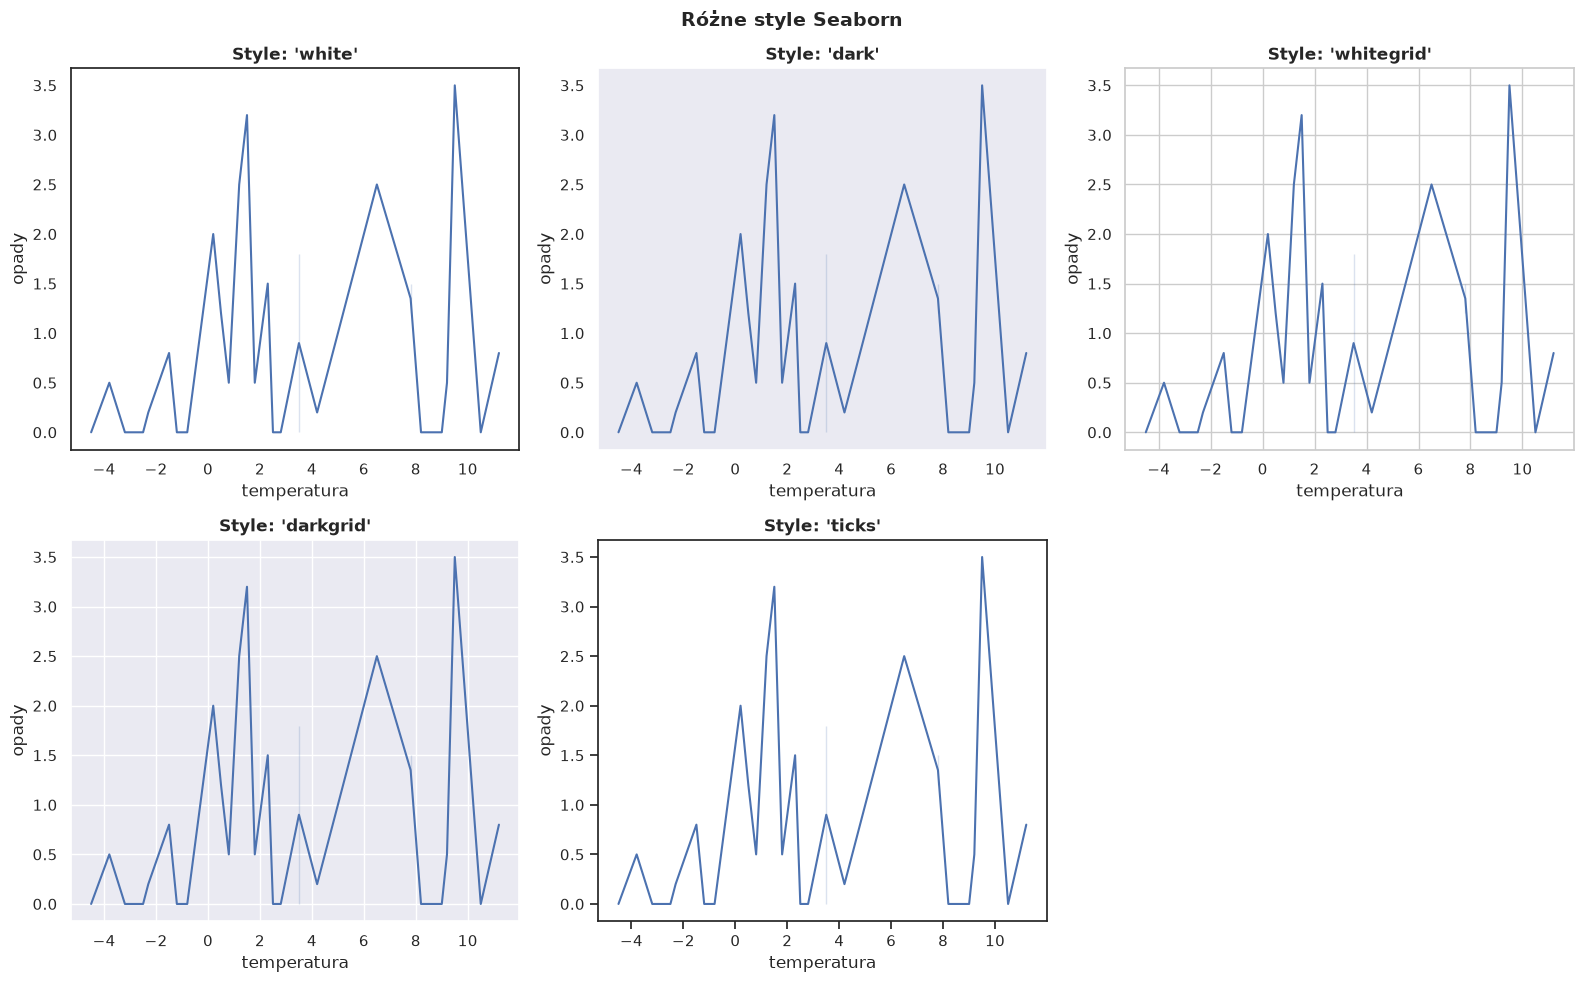

✓ Każdy axes jest tworzony WEWNĄTRZ pętli, ZARAZ PO ustawieniu stylu
  Inaczej wszystkie wykresy mają ostatni styl z pętli!


In [24]:
# Dostępne style
styles = ['white', 'dark', 'whitegrid', 'darkgrid', 'ticks']

fig = plt.figure(figsize=(16, 10))

for i, style in enumerate(styles):
    # WAŻNE: Ustaw styl PRZED utworzeniem axes
    sns.set_style(style)
    
    # Teraz utwórz axes (indeksowanie od 1, nie od 0)
    ax = fig.add_subplot(2, 3, i+1)
    
    # Narysuj wykres
    sns.lineplot(data=df_pogoda.head(30), x='temperatura', y='opady', ax=ax)
    ax.set_title(f"Style: '{style}'", fontsize=12, fontweight='bold')

# Ostatni panel - pusty
ax_empty = fig.add_subplot(2, 3, 6)
ax_empty.axis('off')

plt.suptitle('Różne style Seaborn', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Przywróć domyślny
sns.set_theme()

print("✓ Każdy axes jest tworzony WEWNĄTRZ pętli, ZARAZ PO ustawieniu stylu")
print("  Inaczej wszystkie wykresy mają ostatni styl z pętli!")

**Style:**
- `white` - białe tło, bez siatki
- `dark` - ciemne tło
- `whitegrid` - białe tło ze siatką (domyślny)
- `darkgrid` - ciemne tło ze siatką
- `ticks` - białe tło z tickami (znacznikami)

### 4.2 Palety kolorów (`set_palette`, `color_palette`)

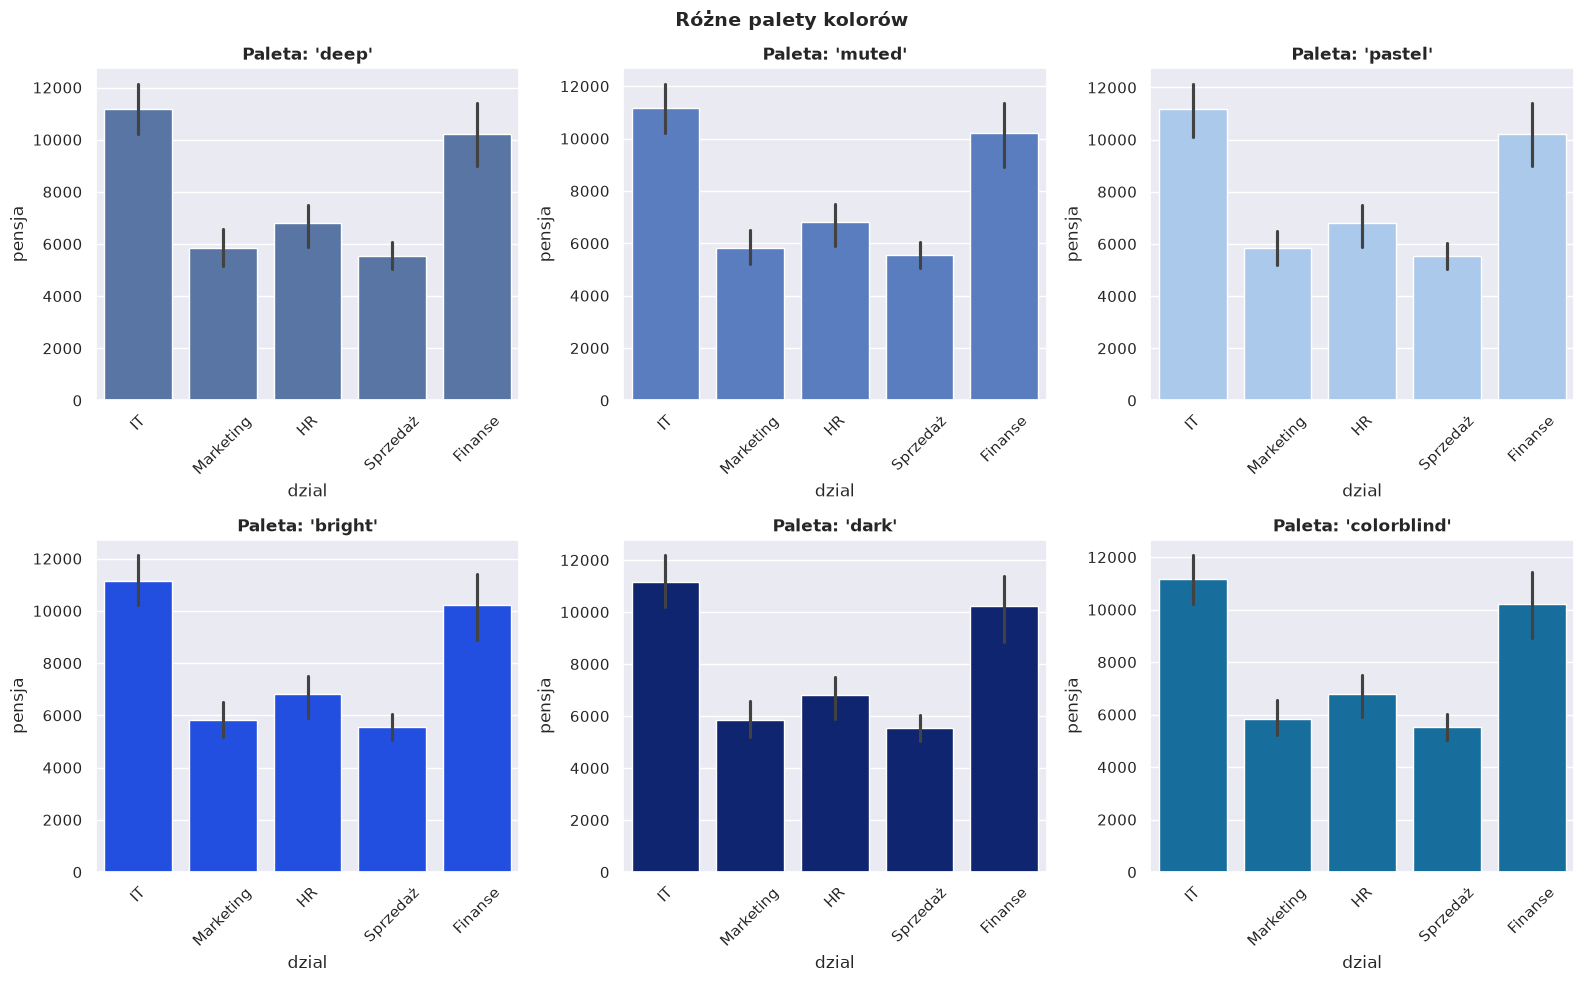

✓ Axes tworzony WEWNĄTRZ pętli - każdy wykres ma swoją paletę!


In [25]:
# Różne palety
palettes = ['deep', 'muted', 'pastel', 'bright', 'dark', 'colorblind']

fig = plt.figure(figsize=(16, 10))

for i, palette in enumerate(palettes):
    # WAŻNE: Ustaw paletę PRZED utworzeniem axes
    sns.set_palette(palette)
    
    # Teraz utwórz axes
    ax = fig.add_subplot(2, 3, i+1)
    
    # Narysuj wykres
    sns.barplot(data=df_prac, x='dzial', y='pensja', ax=ax)
    ax.set_title(f"Paleta: '{palette}'", fontsize=12, fontweight='bold')
    ax.tick_params(axis='x', rotation=45)

plt.suptitle('Różne palety kolorów', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Przywróć domyślną
sns.set_theme()

print("✓ Axes tworzony WEWNĄTRZ pętli - każdy wykres ma swoją paletę!")

**Polecane palety:**
- `deep` - nasycone kolory (domyślna)
- `colorblind` - dla osób z daltonizmem
- `pastel` - delikatne, pastelowe
- `muted` - stonowane

**Inne typy palet:**

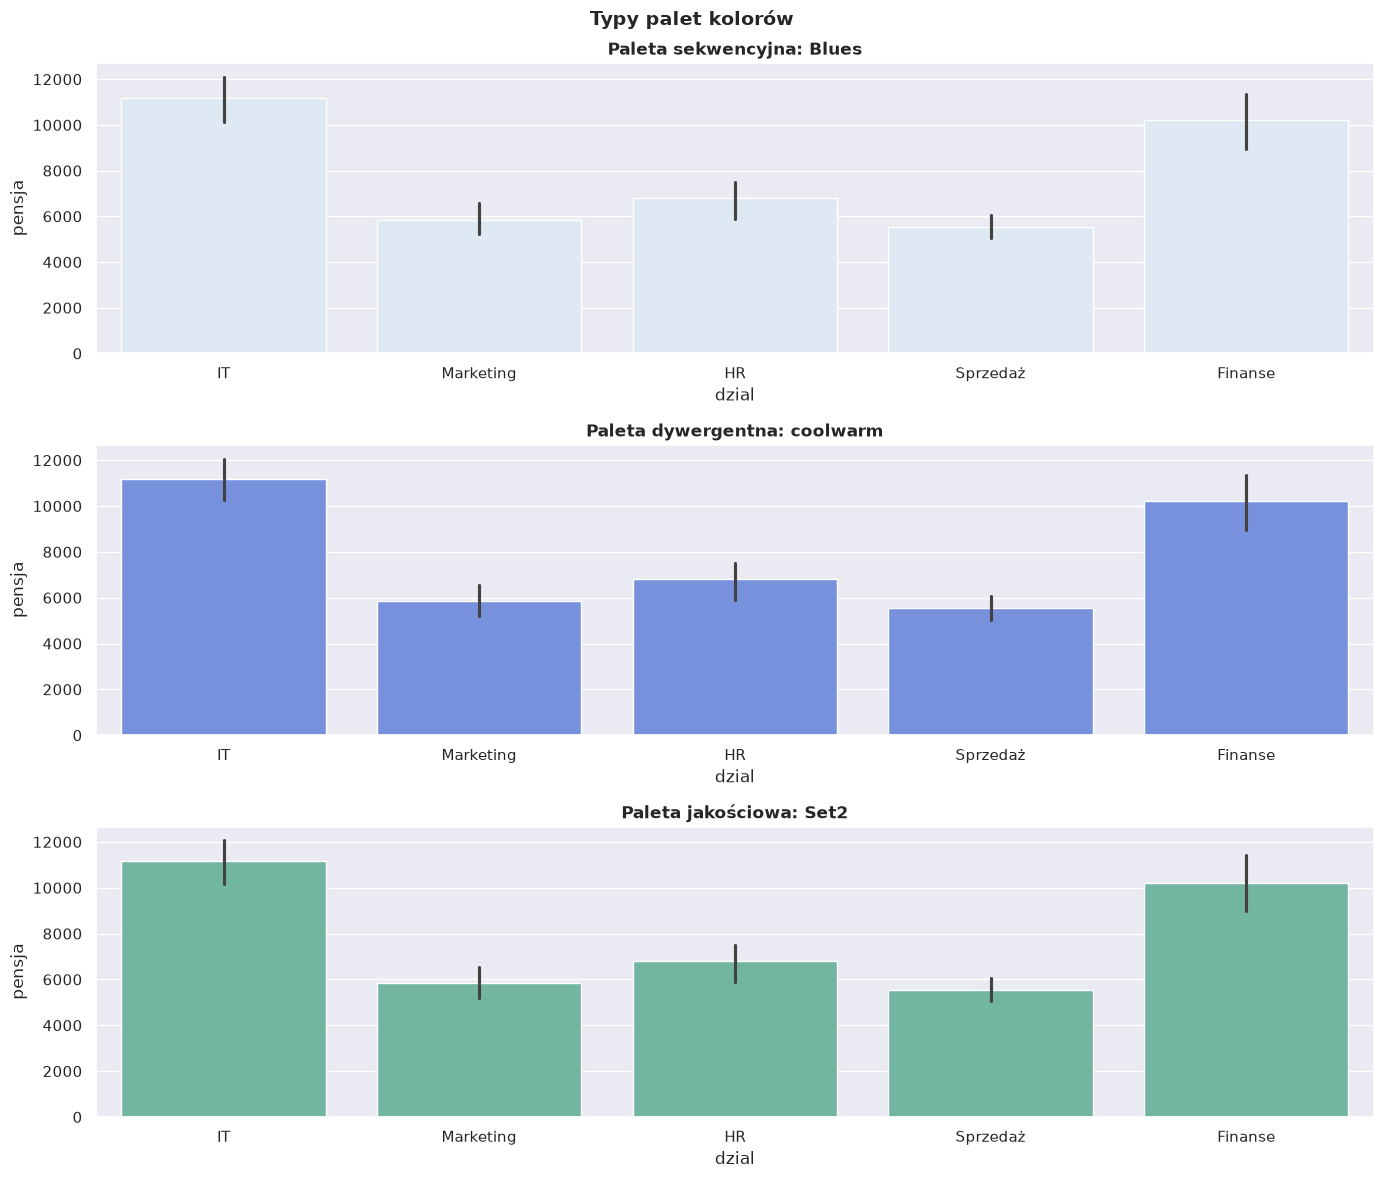

✓ Axes tworzony WEWNĄTRZ pętli - każdy wykres ma swoją paletę!
  - Blues: odcienie niebieskiego (sekwencyjna)
  - coolwarm: niebieski-biały-czerwony (dywergentna)
  - Set2: różne kolory (jakościowa)


In [26]:
# Typy palet
palettes_types = [
    ('Blues', 'Paleta sekwencyjna: Blues'),
    ('coolwarm', 'Paleta dywergentna: coolwarm'),
    ('Set2', 'Paleta jakościowa: Set2')
]

fig = plt.figure(figsize=(14, 12))

for i, (palette, title) in enumerate(palettes_types):
    # WAŻNE: Ustaw paletę PRZED utworzeniem axes
    sns.set_palette(palette)
    
    # Teraz utwórz axes
    ax = fig.add_subplot(3, 1, i+1)
    
    # Narysuj wykres
    sns.barplot(data=df_prac, x='dzial', y='pensja', ax=ax)
    ax.set_title(title, fontsize=12, fontweight='bold')

plt.suptitle('Typy palet kolorów', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

sns.set_theme()

print("✓ Axes tworzony WEWNĄTRZ pętli - każdy wykres ma swoją paletę!")
print("  - Blues: odcienie niebieskiego (sekwencyjna)")
print("  - coolwarm: niebieski-biały-czerwony (dywergentna)")
print("  - Set2: różne kolory (jakościowa)")

### 4.3 Kontekst (`set_context`)

Kontekst kontroluje rozmiar elementów - idealny do różnych zastosowań!

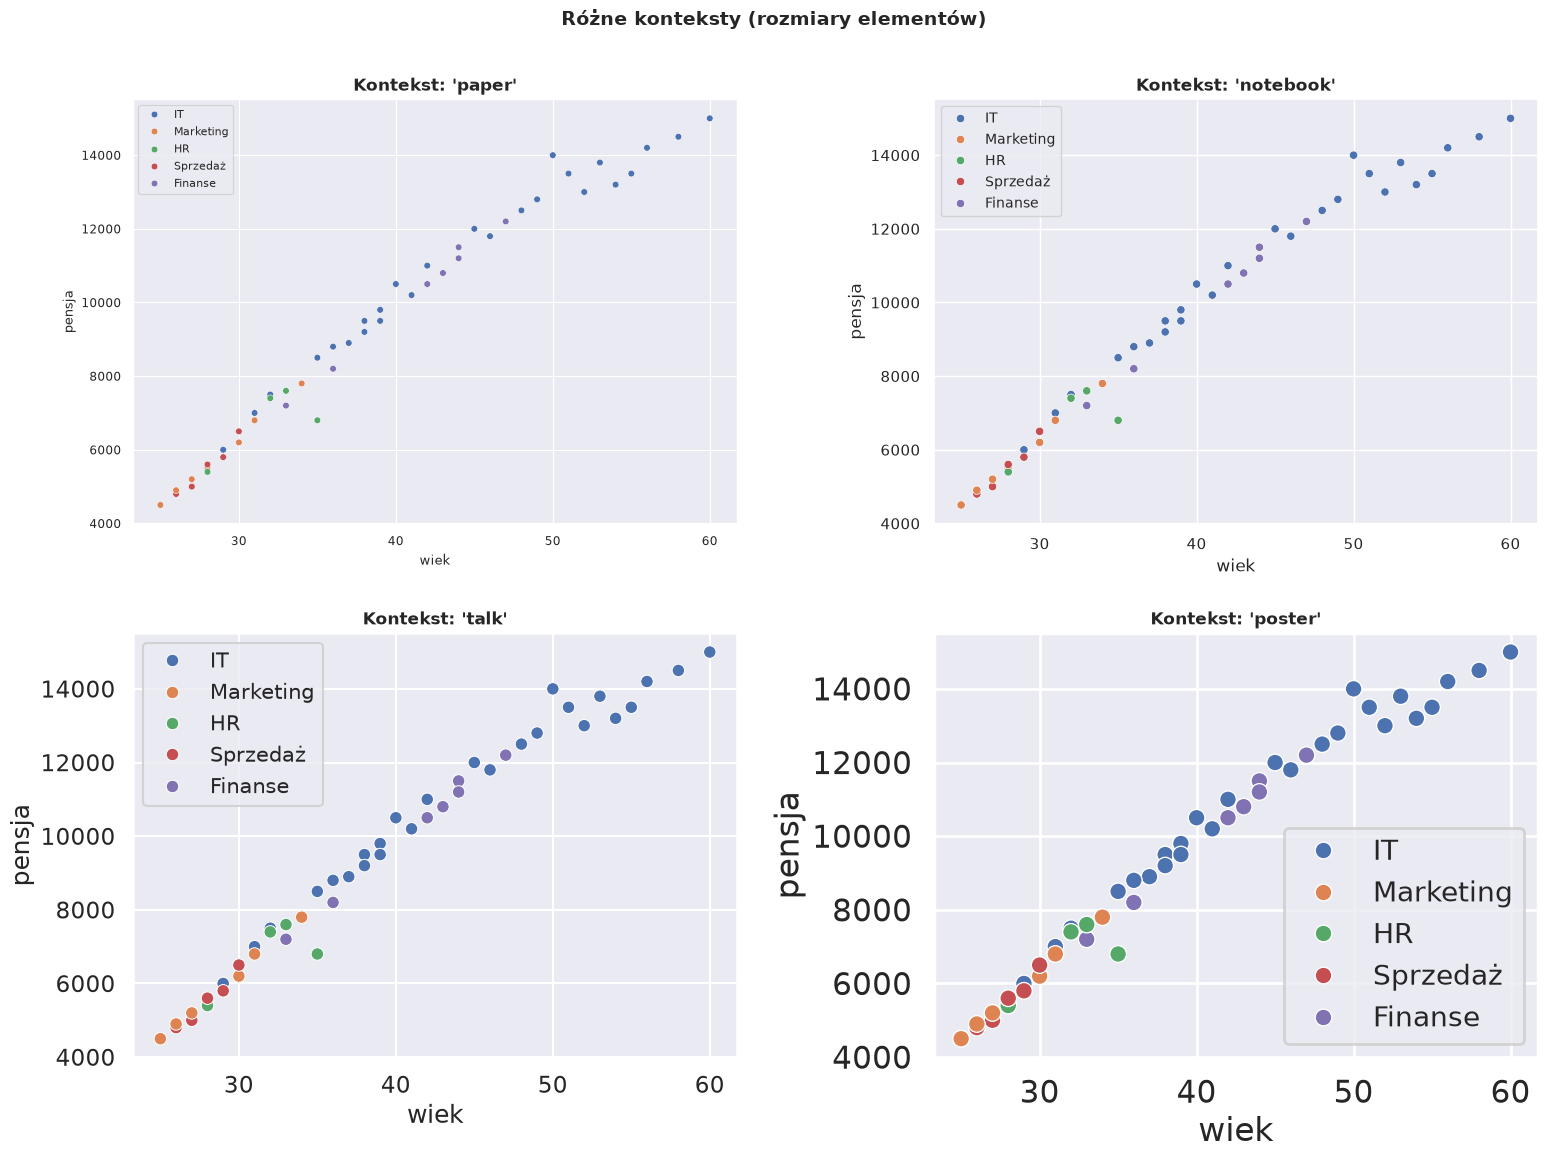

Konteksty:
- 'paper': mały (do publikacji)
- 'notebook': średni (domyślny, do notebooków)
- 'talk': duży (do prezentacji)
- 'poster': bardzo duży (do posterów)

✓ Różnice są SUBTELNE - porównaj rozmiary czcionek i punktów!


In [27]:
# Różne konteksty
contexts = ['paper', 'notebook', 'talk', 'poster']

fig = plt.figure(figsize=(16, 12))

for i, context in enumerate(contexts):
    # WAŻNE: Ustaw kontekst PRZED utworzeniem axes
    sns.set_context(context)
    
    # Teraz utwórz axes
    ax = fig.add_subplot(2, 2, i+1)
    
    # Narysuj wykres
    sns.scatterplot(data=df_prac, x='wiek', y='pensja', hue='dzial', ax=ax)
    ax.set_title(f"Kontekst: '{context}'", fontsize=12, fontweight='bold')
    ax.legend(fontsize='small')

plt.suptitle('Różne konteksty (rozmiary elementów)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Przywróć domyślny
sns.set_context('notebook')

print("Konteksty:")
print("- 'paper': mały (do publikacji)")
print("- 'notebook': średni (domyślny, do notebooków)")
print("- 'talk': duży (do prezentacji)")
print("- 'poster': bardzo duży (do posterów)")
print("\n✓ Różnice są SUBTELNE - porównaj rozmiary czcionek i punktów!")

### 4.4 ⚠️ WAŻNE: Dwa poziomy funkcji w Seaborn - Axes-level vs Figure-level

Do tej pory używaliśmy funkcji seaborn, ale może zauważyliście dziwną rzecz:

- Czasem używamy `plt.xticks()`, `plt.xlabel()` - jak w matplotlib
- Czasem używamy `g.set_xticklabels()`, `g.set_axis_labels()` - zupełnie inny interfejs!

**To nie przypadek!** Seaborn ma **dwa różne poziomy funkcji** z **różnymi interfejsami**. Musisz wiedzieć który używasz!

#### 4.4.1 Axes-level functions - działa jak Matplotlib

**Funkcje niższego poziomu:**

- `scatterplot()`, `lineplot()`, `histplot()`, `kdeplot()`, `boxplot()`, `violinplot()`, `barplot()`, `countplot()` etc.
- Zwracają obiekt **Axes** (ten sam co matplotlib!)
- Działają na pojedynczym wykresie
- Dostosowanie: **normalny matplotlib** → `plt.xticks()`, `plt.xlabel()`, `plt.title()`
- Można używać z `plt.subplots()` do tworzenia własnych layoutów

```python
# Axes-level - działa DOKŁADNIE jak matplotlib
ax = sns.scatterplot(data=df, x='x', y='y')

# Dostosowanie - normalny matplotlib!
plt.xticks(rotation=45)
plt.xlabel('Opis X')
plt.ylabel('Opis Y')
plt.title('Tytuł')
plt.grid(True)
```

**Zalety:**
- ✅ Znasz już matplotlib → nic nowego do nauki
- ✅ Pełna kontrola
- ✅ Łatwo kombinować wiele wykresów na jednej figurze

**Wady:**
- ❌ Brak automatycznego facetingu (podział na panele)

#### 4.4.2 Figure-level functions - inny interfejs!

**Funkcje wyższego poziomu:**

- **`relplot()`** - wykresy relacji (scatter, line)
- **`catplot()`** - wykresy kategoryczne (box, violin, bar, strip, swarm)
- **`displot()`** - wykresy rozkładów (hist, kde)
- `jointplot()`, `pairplot()` - specjalne funkcje

- Zwracają obiekt **FacetGrid** (NIE Axes!)
- Tworzą całą figurę z możliwością wielu paneli (`col`, `row`)
- Dostosowanie: **metody FacetGrid** → `g.set_xticklabels()`, `g.set_axis_labels()`, `g.fig.suptitle()`
- NIE działają z `plt.subplots()` - tworzą własną figurę

```python
# Figure-level - INNY interfejs!
g = sns.relplot(data=df, x='x', y='y', col='kategoria')

# Dostosowanie - METODY na obiekcie g!
g.set_xticklabels(rotation=45, ha='right')  # ← METODA g.set_*
g.set_axis_labels('Opis X', 'Opis Y')       # ← METODA g.set_*
g.fig.suptitle('Tytuł całej figury')        # ← Przez g.fig
```

**Zalety:**
- ✅ Automatyczny **faceting** (podział na panele) - super do eksploracji!
- ✅ Jeden wykres może pokazać dane według wielu kategorii

**Wady:**
- ❌ Inny interfejs niż matplotlib - trzeba się nauczyć
- ❌ Nie można łączyć z innymi wykresami w `plt.subplots()`

#### Przykład - porównanie obu interfejsów

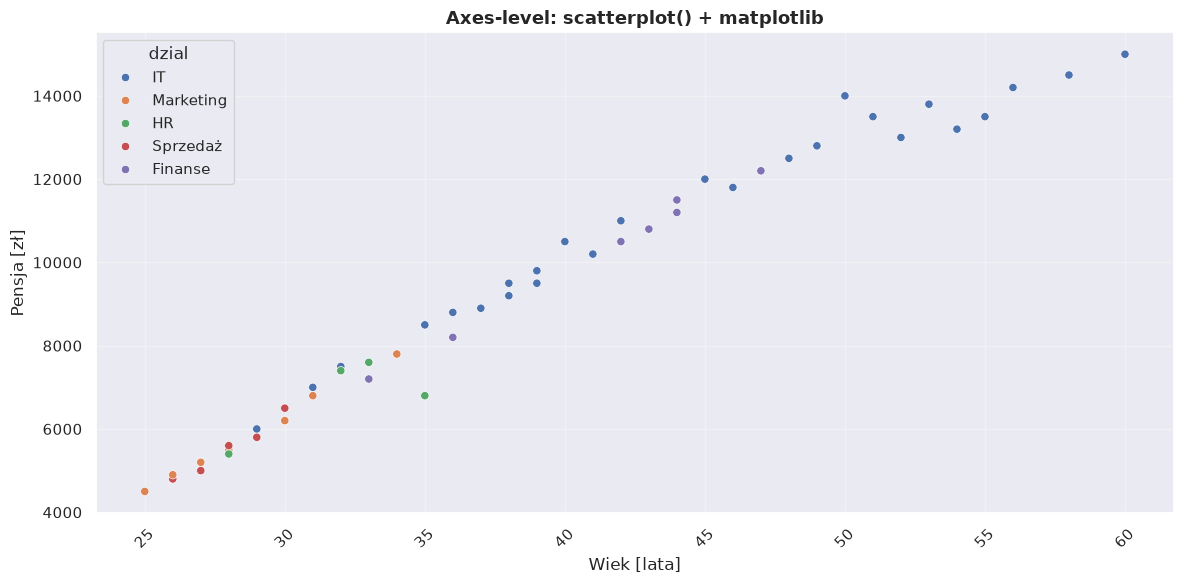

AXES-LEVEL:
✓ Zwraca Axes
✓ Dostosowanie: plt.xticks(), plt.xlabel(), plt.title()
✓ Działa z plt.subplots()
✓ JAK MATPLOTLIB



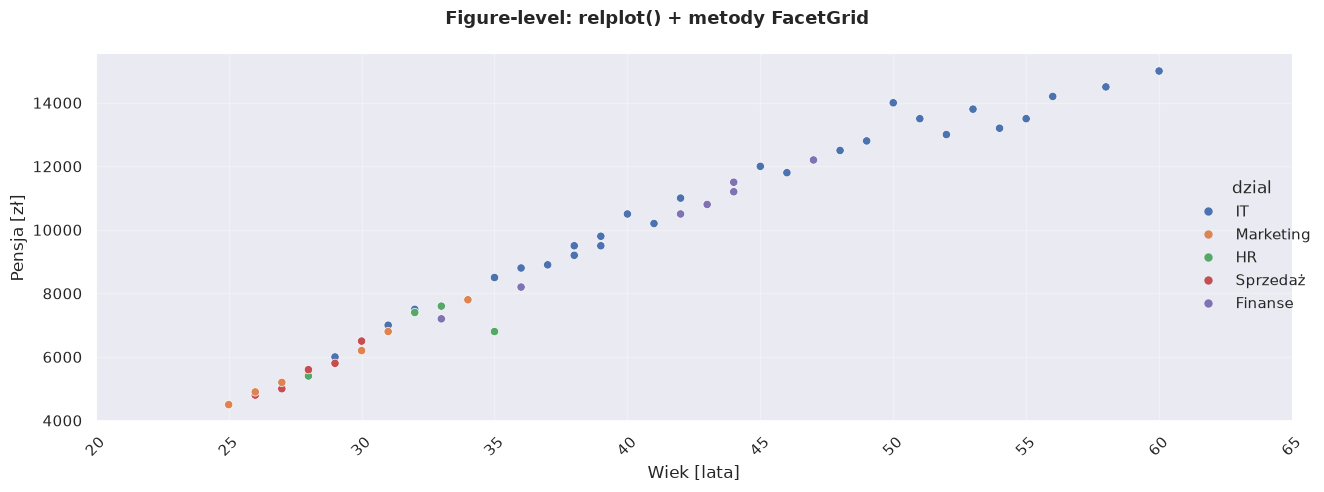

FIGURE-LEVEL:
✓ Zwraca FacetGrid
✓ Dostosowanie: g.set_xticklabels(), g.set_axis_labels(), g.fig.suptitle()
✓ NIE działa z plt.subplots() - tworzy własną figurę!
✓ Zaletą jest FACETING (col, row)

⚠️ UWAGA: To RÓŻNE interfejsy - NIE MYL ICH!


In [28]:
# ========== AXES-LEVEL - jak matplotlib ==========
plt.figure(figsize=(12, 6))

ax = sns.scatterplot(data=df_prac, x='wiek', y='pensja', hue='dzial')

# Dostosowanie MATPLOTLIB-em
plt.xticks(rotation=45)
plt.xlabel('Wiek [lata]', fontsize=12)
plt.ylabel('Pensja [zł]', fontsize=12)
plt.title('Axes-level: scatterplot() + matplotlib', fontsize=13, fontweight='bold')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("=" * 70)
print("AXES-LEVEL:")
print("=" * 70)
print("✓ Zwraca Axes")
print("✓ Dostosowanie: plt.xticks(), plt.xlabel(), plt.title()")
print("✓ Działa z plt.subplots()")
print("✓ JAK MATPLOTLIB")
print()

# ========== FIGURE-LEVEL - inny interfejs ==========
g = sns.relplot(data=df_prac, x='wiek', y='pensja', hue='dzial', 
                kind='scatter', height=5, aspect=2.4)

# Dostosowanie METODAMI FacetGrid (INACZEJ!)
g.set_xticklabels(rotation=45)
g.set_axis_labels('Wiek [lata]', 'Pensja [zł]', fontsize=12)
g.fig.suptitle('Figure-level: relplot() + metody FacetGrid', fontsize=13, fontweight='bold')

# Dostęp do pojedynczych axes (jeśli bardzo trzeba)
for ax in g.axes.flat:
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("=" * 70)
print("FIGURE-LEVEL:")
print("=" * 70)
print("✓ Zwraca FacetGrid")
print("✓ Dostosowanie: g.set_xticklabels(), g.set_axis_labels(), g.fig.suptitle()")
print("✓ NIE działa z plt.subplots() - tworzy własną figurę!")
print("✓ Zaletą jest FACETING (col, row)")
print()
print("⚠️ UWAGA: To RÓŻNE interfejsy - NIE MYL ICH!")

#### Cheat sheet - Jak dostosować wykres?

| Co chcesz zrobić | Axes-level<br>(scatterplot, lineplot, etc.) | Figure-level<br>(relplot, catplot, displot) |
|------------------|--------------------------------|------------------------------|
| **Obrócić etykiety X** | `plt.xticks(rotation=45)`<br>lub `ax.tick_params(axis='x', rotation=45)` | `g.set_xticklabels(rotation=45, ha='right')` |
| **Zmienić opisy osi** | `plt.xlabel('X')` i `plt.ylabel('Y')`<br>lub `ax.set_xlabel('X')` | `g.set_axis_labels('X', 'Y')` |
| **Dodać tytuł** | `plt.title('Tytuł')`<br>lub `ax.set_title('Tytuł')` | `g.fig.suptitle('Tytuł', y=1.02)` |
| **Zmienić rozmiar** | `plt.figure(figsize=(10, 6))` | `height=5, aspect=2`<br>(w wywołaniu funkcji) |
| **Dodać siatkę** | `plt.grid(True)`<br>lub `ax.grid(True)` | `for ax in g.axes.flat:`<br>&nbsp;&nbsp;&nbsp;&nbsp;`ax.grid(True)` |
| **Dostęp do axes** | Masz już `ax` | `g.axes`<br>lub `g.axes.flat` (dla wielu paneli) |

**💡 Złota zasada:**
- **Axes-level** → używaj matplotlib (`plt.*` lub `ax.*`)
- **Figure-level** → używaj metod FacetGrid (`g.*`)

#### Kiedy którego poziomu użyć?

**Używaj AXES-LEVEL gdy:**
- ✅ Chcesz **pełnej kontroli** matplotlib
- ✅ Tworzysz **własny layout** z `plt.subplots()`
- ✅ Chcesz **połączyć wiele różnych wykresów** na jednej figurze
- ✅ Nie potrzebujesz facetingu (podział na panele)

**Używaj FIGURE-LEVEL gdy:**
- ✅ Chcesz **faceting** - automatyczny podział na wiele paneli (`col`, `row`)
- ✅ Chcesz **szybko** zbadać dane według kategorii
- ✅ Jeden wykres wystarczy (nie kombinujesz z innymi)

**Przykład - to samo można zrobić na dwa sposoby:**

```python
# 1. Axes-level - pełna kontrola (DŁUŻSZY KOD)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, kategoria in enumerate(['Komputery', 'Peryferia', 'Audio']):
    dane = df[df['kategoria'] == kategoria]
    sns.scatterplot(data=dane, x='x', y='y', ax=axes[i])
    axes[i].set_title(kategoria)

# 2. Figure-level - automatyczny faceting (KRÓCEJ!)
g = sns.relplot(data=df, x='x', y='y', col='kategoria', kind='scatter')
# 3 panele automatycznie!
```

**Rekomendacja:**
- **Zacznij od axes-level** (jak matplotlib) - prostsze
- **Przejdź na figure-level** gdy potrzebujesz facetingu

#### Podsumowanie - Axes-level vs Figure-level

**Najważniejsze:**

1. **Seaborn ma DWA różne interfejsy**
2. **Axes-level** (scatterplot, lineplot, boxplot, etc.):
   - Zwraca `Axes`
   - Dostosowanie przez **matplotlib** (`plt.*`, `ax.*`)
   - Działa z `plt.subplots()`
3. **Figure-level** (relplot, catplot, displot):
   - Zwraca `FacetGrid`
   - Dostosowanie przez **metody FacetGrid** (`g.set_*`, `g.fig.*`)
   - Przewaga: **faceting** (automatyczny podział na panele)
4. **Możesz łączyć oba** - dostęp do axes przez `g.axes.flat`

**Co zapamiętać:**
- Sprawdź co funkcja zwraca: `Axes` czy `FacetGrid`?
- Jeśli `FacetGrid` → użyj metod `g.*` zamiast `plt.*`
- Nie wiesz? Sprawdź dokumentację lub typ zwracanego obiektu: `type(g)`

---

---
## 5. Matplotlib vs Seaborn - podsumowanie

Ostateczne porównanie!

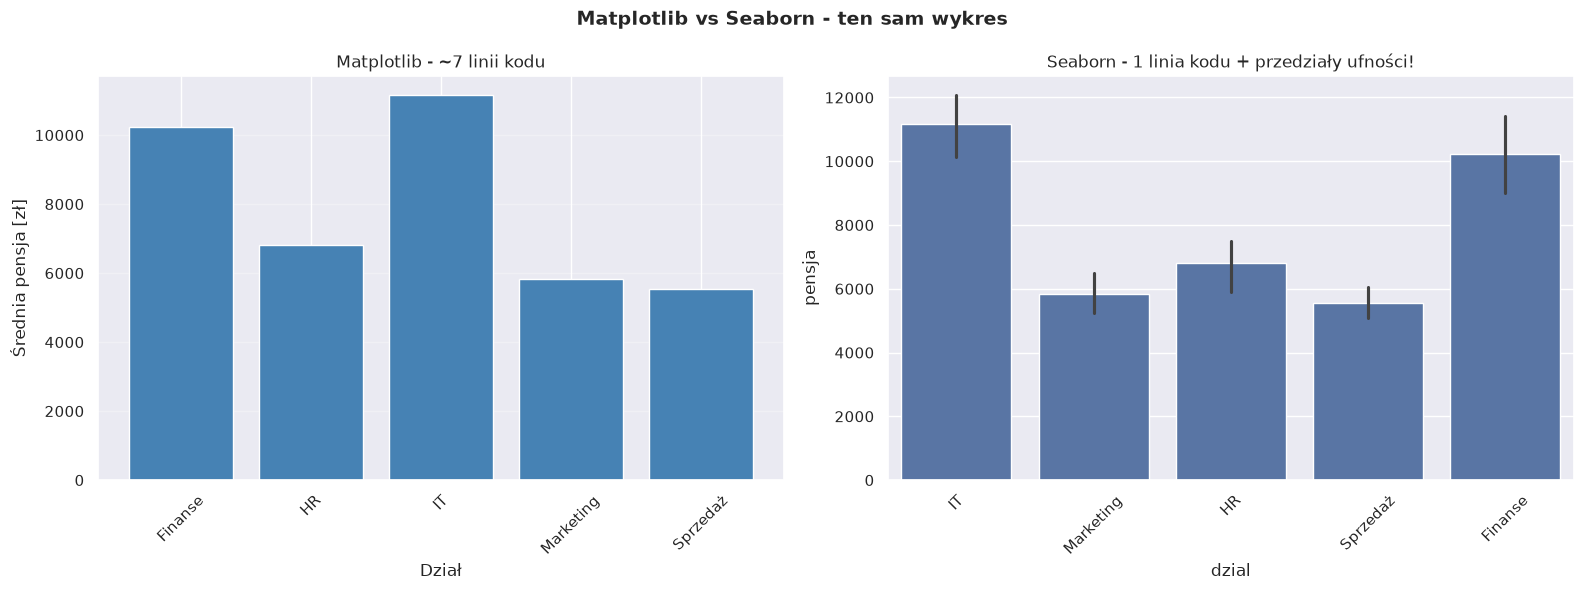


KIEDY KTÓREGO UŻYĆ?

MATplotlib:
✓ Precyzyjna kontrola nad każdym elementem
✓ Niestandardowe, złożone wizualizacje
✓ Gdy Seaborn nie ma danego typu wykresu

SEABORN:
✓ Szybka analiza eksploracyjna
✓ Wykresy statystyczne (przedziały ufności, regresje)
✓ Praca z Pandas DataFrame
✓ Piękne wykresy bez wysiłku

💡 BEST PRACTICE: Używaj Seaborn + Matplotlib razem!
   Seaborn do szybkiego wykresu, Matplotlib do precyzyjnego dostosowania.


In [29]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# MATPLOTLIB - dużo kodu
dzialy = df_prac.groupby('dzial')['pensja'].mean()
axes[0].bar(dzialy.index, dzialy.values, color='steelblue')
axes[0].set_title('Matplotlib - ~7 linii kodu', fontsize=12)
axes[0].set_xlabel('Dział')
axes[0].set_ylabel('Średnia pensja [zł]')
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(axis='y', alpha=0.3)

# SEABORN - 1 linia!
sns.barplot(data=df_prac, x='dzial', y='pensja', ax=axes[1])
axes[1].set_title('Seaborn - 1 linia kodu + przedziały ufności!', fontsize=12)
axes[1].tick_params(axis='x', rotation=45)

plt.suptitle('Matplotlib vs Seaborn - ten sam wykres', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("KIEDY KTÓREGO UŻYĆ?")
print("="*60)
print("\nMATplotlib:")
print("✓ Precyzyjna kontrola nad każdym elementem")
print("✓ Niestandardowe, złożone wizualizacje")
print("✓ Gdy Seaborn nie ma danego typu wykresu")
print("\nSEABORN:")
print("✓ Szybka analiza eksploracyjna")
print("✓ Wykresy statystyczne (przedziały ufności, regresje)")
print("✓ Praca z Pandas DataFrame")
print("✓ Piękne wykresy bez wysiłku")
print("\n💡 BEST PRACTICE: Używaj Seaborn + Matplotlib razem!")
print("   Seaborn do szybkiego wykresu, Matplotlib do precyzyjnego dostosowania.")

---
## Gratulacje! 🎉

# Ukończyłeś cały moduł Seaborn!

## Podsumowanie:

### Część 1:
✅ Wprowadzenie do Seaborn  
✅ Wykresy relacji (`scatterplot`, `lineplot`, `relplot`)  
✅ Wykresy rozkładów (`histplot`, `kdeplot`, `boxplot`, `violinplot`)  

### Część 2:
✅ Wykresy kategoryczne (`barplot`, `countplot`, `catplot`)  
✅ Strip plot i Swarm plot  
✅ Heatmapy i macierze korelacji  
✅ Pairplot - wszystkie zmienne naraz  
✅ Stylowanie (style, palety, konteksty)  
✅ Matplotlib vs Seaborn  

## Co potrafisz teraz:

- Tworzyć piękne wykresy w 1-2 liniach kodu
- Analizować korelacje (heatmapa)
- Szybko eksplorować dane (pairplot)
- Porównywać rozkłady (box plot, violin plot)
- Dostosowywać style i palety
- Łączyć Seaborn z Matplotlib

## Co dalej?

### Notebook 4: Plotly & Dash
- Interaktywne wizualizacje
- Dashboardy webowe
- Zoom, hover, filtrowanie
- Wykresy 3D interaktywne

**Gotowy na interaktywność? Przejdź do Plotly!** 🚀